# Goldstoninator

## Goldstone diagrams from Coulomb-integral products

`goldstoninator.py` builds the time-ordered diagram of a term from its numerator alone: each $g_{pqrs}=\langle pq|g|rs\rangle$ is an interaction line (wavy), each $h_{pr}=\langle p|h|r\rangle$ a one-body vertex (cross) that absorbs an energy $\omega_h$; letters $a,b,c,\ldots$ are core (holes, arrows pointing left), $m,n,r,s,\ldots$ excited (particles, arrows pointing right), $v,w$ valence (in from the top left, out to the right).
The time ordering follows from "particle created before annihilated, hole created before filled"; the energy denominators and the sign follow from the lines crossing each gap. No dependencies; output is SVG (inline), PDF, TikZ source, or LaTeX text (typeset inline).

In [1]:
import goldstoninator as gd

One term (any of `g_vbms`, `g_{vbms}`, `g[v,b,m,s]`, or a list of tuples):

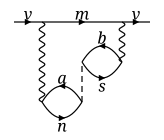

In [2]:
gd.diagram("g_vbms x_asnb g_mnva")

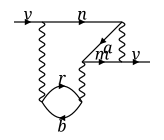

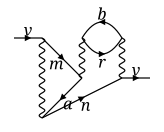

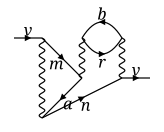

In [3]:
diagram1 = gd.diagram(r"g_{vbnr} g_{vamn} g_{mbar}")
diagram2 = gd.diagram(r"g_{vbnr} g_{mnva} g_{mbar}")
display(diagram1, diagram2)
display(diagram2)

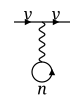

In [4]:
gd.diagram("g_vnvn")

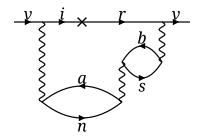

In [5]:
gd.diagram("g_vbrs A_ri g_asnb  g_inva")

Several terms side by side:

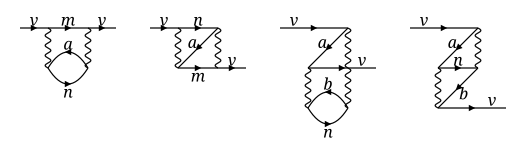

In [6]:
gd.grid(["g_vamn g_mnva", "g_vamn g_mnav", "g_abvn g_vnab", "g_abvn g_vnba"], ncols=4)

Other interaction lines (`wavy`, `dashed`, `dotted`, `double`, `solid`; unknown names are dashed) and extra margin:

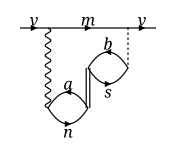

In [7]:
gd.diagram("S_vbms l_asnb g_mnva", styles={"S": "dotted", "l": "double"}, pad=0.5)

One-body vertex (two indices, e.g. an external field $h_{na}$), drawn as a cross by default (`styles={'h': 'dot'}` for a dot; also `circle`, `square`). Two cases: the field acts before or after the Coulomb interaction:

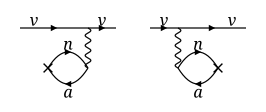

In [8]:
gd.grid(["h_na g_vavn", "g_vnva h_an"], ncols=2)

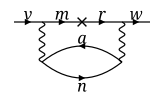

In [9]:
a = gd.diagram("g_warn t_rm g_mnva")
display(a)

The term as LaTeX: sign, numerator as given, energy denominators (valence energy first and positive):

In [10]:
print(gd.diagram("g_vbms g_asnb g_mnva").tex())

+\frac{g_{vbms}\,g_{asnb}\,g_{mnva}}{(\varepsilon_{va}-\varepsilon_{mn})(\varepsilon_{vb}-\varepsilon_{ms})}


The sum of several terms (each with its own sign):

In [11]:
print(
    gd.grid(["g_vamn g_mnva", "g_vamn g_mnav", "g_abvn g_vnab", "g_abvn g_vnba"]).tex()
)

+\frac{g_{vamn}\,g_{mnva}}{(\varepsilon_{va}-\varepsilon_{mn})}
-\frac{g_{vamn}\,g_{mnav}}{(\varepsilon_{va}-\varepsilon_{mn})}
+\frac{g_{abvn}\,g_{vnab}}{(\varepsilon_{vn}-\varepsilon_{ab})}
-\frac{g_{abvn}\,g_{vnba}}{(\varepsilon_{vn}-\varepsilon_{ab})}


`.equation()` gives the same LaTeX as an object that Jupyter typesets when it is the output of a cell (`print()` it, or `str()`, for the source):

In [12]:
gd.grid(["g_vamn g_mnva", "g_vamn g_mnav", "g_abvn g_vnab", "g_abvn g_vnba"]).equation()

$$\begin{aligned}
&+\frac{g_{vamn}\,g_{mnva}}{(\varepsilon_{va}-\varepsilon_{mn})} \\
&-\frac{g_{vamn}\,g_{mnav}}{(\varepsilon_{va}-\varepsilon_{mn})} \\
&+\frac{g_{abvn}\,g_{vnab}}{(\varepsilon_{vn}-\varepsilon_{ab})} \\
&-\frac{g_{abvn}\,g_{vnba}}{(\varepsilon_{vn}-\varepsilon_{ab})}
\end{aligned}$$

## External field: the energy $\omega$

A one-body vertex stands for an external field (or any effective one-body operator) and is taken to *absorb* an energy $\omega_h$ (subscript: the name of the vertex), which enters the energy denominators after it. The final valence energy never appears: energy conservation $\varepsilon_w=\varepsilon_v+\sum\omega$ removes it, and the denominators are simplified. So the two time orderings of the field vertex give $\varepsilon_a-\varepsilon_n\pm\omega_h$:

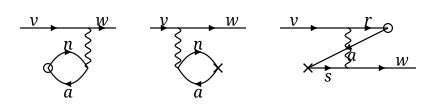

In [13]:
rpa = gd.grid(
    ["s_na g_wavn", "g_wnva t_an", "s_ra g_rwvs t_sa"],
    styles={"s": "circle", "t": "x"},
    ncols=3,
)
display(rpa)

Or, set globally:

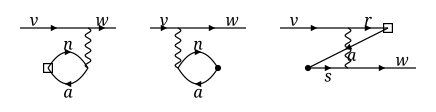

In [14]:
gd.STYLES["s"] = "square"
gd.STYLES["t"] = "dot"

gd.grid(["s_na g_wavn", "g_wnva t_an", "s_ra g_rwvs t_sa"], ncols=3)

In [15]:
rpa.equation()

$$\begin{aligned}
&+\frac{s_{na}\,g_{wavn}}{(\varepsilon_a-\varepsilon_n+\omega_s)} \\
&+\frac{g_{wnva}\,t_{an}}{(\varepsilon_a-\varepsilon_n-\omega_t)} \\
&-\frac{s_{ra}\,g_{rwvs}\,t_{sa}}{(\varepsilon_a-\varepsilon_s+\omega_t)(\varepsilon_a-\varepsilon_r-\omega_s)}
\end{aligned}$$

`omega=False` for a static field (no $\omega$; then $\varepsilon_w$ is kept where it occurs), `omega=r'\omega'` for a plain symbol, or a dict `omega={'h': r'\omega', 'S': True}` to choose the symbol per name (`True`: $\omega_{\rm name}$; any vertex may be given one). The symbol is `gd.OMEGA`.

In [16]:
print(gd.diagram("g_wnva h_an", omega=False).tex())
gd.diagram("h_na g_wavn", omega=r"\omega").equation()

+\frac{g_{wnva}\,h_{an}}{(\varepsilon_{va}-\varepsilon_{wn})}


$$+\frac{h_{na}\,g_{wavn}}{(\varepsilon_a-\varepsilon_n+\omega)}$$

Save a diagram or a grid as SVG, PDF, or TikZ (`.tikz`: a `tikzpicture` to `\input`; `.tex`: a standalone document):

In [17]:
example = gd.diagram(
    "g_vbrs g_asnb t_rm g_mnva", styles={"t": "cross"}
)  # the README example
example.save("example.pdf")
example.save("example.svg")
gd.grid(["g_vamn g_mnva", "g_abvn g_vnab"]).save("example-grid.svg")

'example-grid.svg'

The TikZ source (`.tikz()`; the same geometry as the pictures, 1 unit = `unit` cm; wavy lines need `\usetikzlibrary{decorations.pathmorphing}`, and `.tikz(standalone=True)` is a complete document):

In [18]:
print(gd.diagram("h_na g_vavn").tikz())

% h_na g_vavn
\begin{tikzpicture}[x=1cm,y=1cm,line width=0.85pt]
\draw[decorate,decoration={snake,amplitude=0.7mm,segment length=2.5mm}] (1,0) -- (1,-1);
\draw[line width=1pt] (-0.11,-1.11) -- (0.11,-0.89) (-0.11,-0.89) -- (0.11,-1.11);
\draw (-0.7,0) -- (1,0);
\draw (1,0) -- (1.7,0);
\draw (0,-1) .. controls (0.33,-0.47) and (0.67,-0.47) .. (1,-1);
\draw (1,-1) .. controls (0.67,-1.53) and (0.33,-1.53) .. (0,-1);
\fill (0.58,-0.6) -- (0.42,-0.52) -- (0.42,-0.68) -- cycle;
\fill (0.42,-1.4) -- (0.58,-1.48) -- (0.58,-1.32) -- cycle;
\fill (0.23,0) -- (0.07,0.08) -- (0.07,-0.08) -- cycle;
\fill (1.43,0) -- (1.27,0.08) -- (1.27,-0.08) -- cycle;
\node at (0.5,-0.4) {$n$};
\node at (0.5,-1.6) {$a$};
\node at (-0.35,0.2) {$v$};
\node at (1.35,0.2) {$v$};
\end{tikzpicture}


Letter classes can be changed: `gd.diagram('g_vbms g_asnb g_mnva', core='abcd', exc='mnrs', val='v')`; the energy symbols are `gd.EPS` and `gd.OMEGA`.

## Just another example

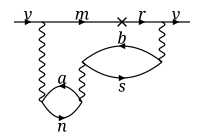

+\frac{g_{vbrs}\,g_{asnb}\,t_{rm}\,g_{mnva}}{(\varepsilon_{va}-\varepsilon_{mn})(\varepsilon_{vb}-\varepsilon_{ms})(\varepsilon_{vb}-\varepsilon_{rs}+\omega_t)}


$$+\frac{g_{vbrs}\,g_{asnb}\,t_{rm}\,g_{mnva}}{(\varepsilon_{va}-\varepsilon_{mn})(\varepsilon_{vb}-\varepsilon_{ms})(\varepsilon_{vb}-\varepsilon_{rs}+\omega_t)}$$

In [19]:
example = gd.diagram(
    "g_vbrs g_asnb t_rm g_mnva",
    styles={"t": "cross"},
)

display(example)

print(example.tex())

example.equation()